In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, average_precision_score, fbeta_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedBaggingClassifier, BalancedRandomForestClassifier

# Define features and target variable

In [2]:
# Define features and target variable
features = [
    # encoded station/service
    'StationCode_TE',
    'Service:Type_Intercity',
    'Service:Type_Intercity direct',
    'Service:Type_Sprinter',
    # temporal
    'Hour_sin',
    'Hour_cos',
    'DayOfWeek_sin',
    'DayOfWeek_cos',
    'Month_sin',
    'Month_cos',
    'IsWeekend',
    'RushHour',
    # operational context
    'StationTraffic',
    'Stop:Platform change',
    'arrival_scheduled',
    'departure_scheduled',
    # weather
    'Wind Direction',
    'Hourly Mean Wind Speed',
    'Wind Speed last 10 Minutes',
    'Max Wind Speed',
    'Temperature',
    'Dew Point temperature',
    'Sunshine Duration',
    'Global Radiation',
    'Precipitation Duration',
    'Precipitation Amount',
    'Air Pressure',
    'Horizontal Visibility',
    'Cloud Cover',
    'Humidity',
    'Fog',
    'Rainfall',
    'Snowfall',
    'Thunder',
    'Hail',
]

target = "is_cancelled"

# Define chunck reader function

In [3]:
# Prepare for chunked reading
cols = features + [target]
chunk_size = 1_000_000
sample_size = 1_000_000
random_state = 42

dtype_map = {col: "float32" for col in features}
dtype_map[target] = "int8"


# Read CSV in chunks
def chunk_reader(file_path):
    for chunk in pd.read_csv(
        file_path,
        usecols=cols,
        dtype=dtype_map,
        chunksize=chunk_size
    ):
        chunk = chunk.reindex(columns=cols, fill_value=0) # Ensure all columns are present

        X_chunk = chunk[features]
        y_chunk = chunk[target]

        yield X_chunk, y_chunk # Yield the chunk for processing
        
# Count classes
not_cancelled_total = 0
cancelled_total = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):
    not_cancelled_total += (y_chunk == 0).sum()
    cancelled_total += (y_chunk == 1).sum()

total_rows = not_cancelled_total + cancelled_total

print(f"Train not cancelled: {not_cancelled_total:,}")
print(f"Train cancelled: {cancelled_total:,}")
print(f"Train total:     {total_rows:,}")

# Decide sample sizes
not_cancelled_sample_size = int(sample_size * not_cancelled_total / total_rows)
cancelled_sample_size = sample_size - not_cancelled_sample_size

print(f"Sampling not cancelled: {not_cancelled_sample_size:,}")
print(f"Sampling cancelled: {cancelled_sample_size:,}")

Train not cancelled: 43,903,090
Train cancelled: 4,479,366
Train total:     48,382,456
Sampling not cancelled: 907,417
Sampling cancelled: 92,583


# Define cancelled/not-cancelled

In [4]:
# Generate random numbers for sampling (default_rng is faster)
rng = np.random.default_rng(random_state)

X_not_cancelled_parts = []
y_not_cancelled_parts = []
X_cancelled_parts = []
y_cancelled_parts = []

not_cancelled_seen = 0
cancelled_seen = 0

for X_chunk, y_chunk in chunk_reader("train_data.csv"):

    # Create masks for cancelled and not cancelled
    not_cancelled_mask = y_chunk == 0
    cancelled_mask = y_chunk == 1
    
    # Split the chunk into cancelled and not cancelled
    X_not_cancelled = X_chunk.loc[not_cancelled_mask]
    y_not_cancelled = y_chunk.loc[not_cancelled_mask]

    X_cancelled = X_chunk.loc[cancelled_mask]
    y_cancelled = y_chunk.loc[cancelled_mask]

    # sample fraction based on remaining needed / remaining available
    neg_remaining_needed = not_cancelled_sample_size - sum(len(p) for p in y_not_cancelled_parts)
    pos_remaining_needed = cancelled_sample_size - sum(len(p) for p in y_cancelled_parts)

    neg_remaining_total = not_cancelled_total - not_cancelled_seen
    pos_remaining_total = cancelled_total - cancelled_seen

    # Sample not cancelled
    if neg_remaining_needed > 0 and len(X_not_cancelled) > 0:
        p_neg = min(1.0, neg_remaining_needed / max(neg_remaining_total, 1))
        keep_neg = rng.random(len(X_not_cancelled)) < p_neg

        X_not_cancelled_parts.append(X_not_cancelled.loc[keep_neg])
        y_not_cancelled_parts.append(y_not_cancelled.loc[keep_neg])
        
    # Sample cancelled
    if pos_remaining_needed > 0 and len(X_cancelled) > 0:
        p_pos = min(1.0, pos_remaining_needed / max(pos_remaining_total, 1))
        keep_pos = rng.random(len(X_cancelled)) < p_pos

        X_cancelled_parts.append(X_cancelled.loc[keep_pos])
        y_cancelled_parts.append(y_cancelled.loc[keep_pos])

    not_cancelled_seen += len(X_not_cancelled)
    cancelled_seen += len(X_cancelled)

# Combine sampled parts
X_train_sample = pd.concat(X_not_cancelled_parts + X_cancelled_parts, axis=0)
y_train_sample = pd.concat(y_not_cancelled_parts + y_cancelled_parts, axis=0)

# Shuffle final sample
shuffle_idx = rng.permutation(len(X_train_sample))
X_train_sample = X_train_sample.iloc[shuffle_idx].to_numpy(dtype=np.float32, copy=False)
y_train_sample = y_train_sample.iloc[shuffle_idx].to_numpy(dtype=np.int8, copy=False)

# Define Evaluation Method

In [5]:
# Evaluate CSV split in chunks with custom threshold
def evaluate_split_rf(name, file_path, model, threshold):
    y_true_parts = []
    y_pred_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_pred_parts.append(y_pred)
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_pred_all = np.concatenate(y_pred_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    f2 = fbeta_score(y_true_all, y_pred_all, beta=2)
    pr_auc = average_precision_score(y_true_all, y_prob_all)

    print(f"\n{name}")
    print("Threshold:", round(threshold, 2))
    print("F2 Score:", round(f2, 4))
    print(classification_report(y_true_all, y_pred_all, digits=3, zero_division=0))
    print("PR-AUC:", round(pr_auc, 4))

    return {
        "threshold": threshold,
        "f2": f2,
        "pr_auc": pr_auc
    }


# Find best threshold using validation data
def find_best_threshold_rf(file_path, model):
    y_true_parts = []
    y_prob_parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]

        y_true_parts.append(y_chunk.to_numpy(copy=False))
        y_prob_parts.append(y_prob)

    y_true_all = np.concatenate(y_true_parts)
    y_prob_all = np.concatenate(y_prob_parts)

    best_threshold = 0.5
    best_f2 = -1

    for threshold in np.arange(0.01, 0.99, 0.01):
        y_pred_all = (y_prob_all >= threshold).astype(int)
        f2 = fbeta_score(y_true_all, y_pred_all, beta=2)

        if f2 > best_f2:
            best_f2 = f2
            best_threshold = threshold

    print("Best validation threshold:", round(best_threshold, 2))
    print("Best validation F2:", round(best_f2, 4))

    return best_threshold

# Finding the best parameters

In [ ]:
# Custom F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

# Parameter grid for imbalance
param_dist = {
    "n_estimators": [50, 100, 300, 500],
    "max_depth": [10, 15, 20, 50],
    "min_samples_split": [5, 10, 20, 50, 100],
    "min_samples_leaf": [2, 5, 10, 20, 50],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "class_weight": [
        "balanced",
        "balanced_subsample",
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 15},
        {0: 1, 1: 20}
    ],
    "criterion": ["gini", "entropy"]
}

# Use smaller subset for tuning
X_tune, X_val_tune, y_tune, y_val_tune = train_test_split(
    X_train_sample,
    y_train_sample,
    train_size=0.3,
    stratify=y_train_sample,
    random_state=42
)

# Stratified 5-fold CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Base Random Forest
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Random search
rf_tuned = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f2_scorer,
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_tune, y_tune)
s
print(f"Best CV F2 score: {rf_tuned.best_score_:.4f}")
print("Best parameters:")
print(rf_tuned.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV F2 score: 0.4280
Best parameters:
{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 50, 'criterion': 'gini', 'class_weight': {0: 1, 1: 20}}


# Random Forest: Balanced Bagging

In [16]:
# Final model training with best parameters
# Base tree used inside the balanced bagging ensemble
base_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=50,
    max_features="sqrt",
    criterion="gini",
    random_state=42
)

# Final Balanced Bagging Classifier
bbc = BalancedBaggingClassifier(
    estimator=base_tree,
    n_estimators=500,
    sampling_strategy="auto",
    replacement=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


bbc.fit(X_train_sample, y_train_sample)

print("Balanced Bagging Classifier trained on", len(y_train_sample), "samples")

best_threshold = find_best_threshold_rf("val_data.csv", bbc)

train_results = evaluate_split_rf(
    name="Train",
    file_path="train_data.csv",
    model=bbc,
    threshold=best_threshold
)

val_results = evaluate_split_rf(
    name="Validation",
    file_path="val_data.csv",
    model=bbc,
    threshold=best_threshold
)

test_results = evaluate_split_rf(
    name="Test",
    file_path="test_data.csv",
    model=bbc,
    threshold=best_threshold
)

Balanced Bagging Classifier trained on 999797 samples
Best validation threshold: 0.41
Best validation F2: 0.3807

Train
Threshold: 0.41
F2 Score: 0.4107
              precision    recall  f1-score   support

           0      0.965     0.453     0.617  43903090
           1      0.135     0.837     0.233   4479366

    accuracy                          0.489  48382456
   macro avg      0.550     0.645     0.425  48382456
weighted avg      0.888     0.489     0.581  48382456

PR-AUC: 0.2821

Validation
Threshold: 0.41
F2 Score: 0.3807
              precision    recall  f1-score   support

           0      0.940     0.440     0.600   9333880
           1      0.129     0.746     0.219   1033789

    accuracy                          0.471  10367669
   macro avg      0.534     0.593     0.410  10367669
weighted avg      0.859     0.471     0.562  10367669

PR-AUC: 0.1645

Test
Threshold: 0.41
F2 Score: 0.4318
              precision    recall  f1-score   support

           0      0.931 

# Random Forest: Balanced Random Forest Classifier

In [32]:
# Final model training with best parameters
brf = BalancedRandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    sampling_strategy="auto",
    replacement=True,
    criterion="gini",
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train_sample, y_train_sample)

print(f"Balanced Random Forest trained on {len(y_train_sample):,} samples")

best_threshold = find_best_threshold_rf("val_data.csv", brf)

train_results = evaluate_split_rf(
    "Train",
    "train_data.csv",
    brf,
    best_threshold
)

val_results = evaluate_split_rf(
    "Validation",
    "val_data.csv",
    brf,
    best_threshold
)

test_results = evaluate_split_rf(
    "Test",
    "test_data.csv",
    brf,
    best_threshold
)

Balanced Random Forest trained on 999,797 samples
Best validation threshold: 0.4
Best validation F2: 0.3808

Train
Threshold: 0.4
F2 Score: 0.421
              precision    recall  f1-score   support

           0      0.970     0.446     0.611  43903090
           1      0.138     0.867     0.238   4479366

    accuracy                          0.485  48382456
   macro avg      0.554     0.656     0.424  48382456
weighted avg      0.893     0.485     0.577  48382456

PR-AUC: 0.3269

Validation
Threshold: 0.4
F2 Score: 0.3808
              precision    recall  f1-score   support

           0      0.941     0.420     0.581   9333880
           1      0.127     0.761     0.218   1033789

    accuracy                          0.454  10367669
   macro avg      0.534     0.591     0.399  10367669
weighted avg      0.860     0.454     0.545  10367669

PR-AUC: 0.1644

Test
Threshold: 0.4
F2 Score: 0.4327
              precision    recall  f1-score   support

           0      0.932     0.397

# Random Forest: RandomUnderSampling 

In [7]:
# Random undersampling to balance classes
print("Before undersampling:", Counter(y_train_sample))

rus = RandomUnderSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_under, y_train_under = rus.fit_resample(
    X_train_sample,
    y_train_sample
)

print("After undersampling:", Counter(y_train_under))

rf_rus = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight={0: 1, 1: 20},
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

rf_rus.fit(X_train_under, y_train_under)

print(f"Random Forest trained on {len(y_train_under):,} samples")

best_threshold = find_best_threshold_rf("val_data.csv", rf_rus)

train_results = evaluate_split_rf(
    name="Train",
    file_path="train_data.csv",
    model=rf_rus,
    threshold=best_threshold
)

val_results = evaluate_split_rf(
    name="Validation",
    file_path="val_data.csv",
    model=rf_rus,
    threshold=best_threshold
)

test_results = evaluate_split_rf(
    name="Test",
    file_path="test_data.csv",
    model=rf_rus,
    threshold=best_threshold
)

Before undersampling: Counter({np.int8(0): 907281, np.int8(1): 92516})
After undersampling: Counter({np.int8(0): 370064, np.int8(1): 92516})
Random Forest trained on 462,580 samples
Best validation threshold: 0.59
Best validation F2: 0.3808

Train
Threshold: 0.59
F2 Score: 0.4202
              precision    recall  f1-score   support

           0      0.974     0.416     0.583  43903090
           1      0.135     0.892     0.234   4479366

    accuracy                          0.460  48382456
   macro avg      0.555     0.654     0.409  48382456
weighted avg      0.897     0.460     0.551  48382456

PR-AUC: 0.3144

Validation
Threshold: 0.59
F2 Score: 0.3808
              precision    recall  f1-score   support

           0      0.941     0.420     0.580   9333880
           1      0.127     0.762     0.218   1033789

    accuracy                          0.454  10367669
   macro avg      0.534     0.591     0.399  10367669
weighted avg      0.860     0.454     0.544  10367669

PR-AU

# Random Forest: RandomOverSampler

In [19]:
# Random oversampling to balance classes
print("Before oversampling:", Counter(y_train_sample))

ros = RandomOverSampler(
    sampling_strategy=0.25,
    random_state=42
)

X_train_over, y_train_over = ros.fit_resample(
    X_train_sample,
    y_train_sample
)

print("After oversampling:", Counter(y_train_over))

rf_ros = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight={0: 1, 1: 20},
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

rf_ros.fit(X_train_over, y_train_over)

print(f"Random Forest trained on {len(y_train_over):,} samples")

best_threshold = find_best_threshold_rf("val_data.csv", rf_ros)

train_results = evaluate_split_rf(
    name="Train",
    file_path="train_data.csv",
    model=rf_ros,
    threshold=best_threshold
)

val_results = evaluate_split_rf(
    name="Validation",
    file_path="val_data.csv",
    model=rf_ros,
    threshold=best_threshold
)

test_results = evaluate_split_rf(
    name="Test",
    file_path="test_data.csv",
    model=rf_ros,
    threshold=best_threshold
)

Before oversampling: Counter({np.int8(0): 907281, np.int8(1): 92516})
After oversampling: Counter({np.int8(0): 907281, np.int8(1): 226820})
Random Forest trained on 1,134,101 samples
Best validation threshold: 0.46
Best validation F2: 0.3782

Train
Threshold: 0.46
F2 Score: 0.4229
              precision    recall  f1-score   support

           0      0.977     0.407     0.575  43903090
           1      0.135     0.906     0.235   4479366

    accuracy                          0.454  48382456
   macro avg      0.556     0.657     0.405  48382456
weighted avg      0.899     0.454     0.544  48382456

PR-AUC: 0.3507

Validation
Threshold: 0.46
F2 Score: 0.3782
              precision    recall  f1-score   support

           0      0.941     0.376     0.537   9333880
           1      0.123     0.788     0.212   1033789

    accuracy                          0.417  10367669
   macro avg      0.532     0.582     0.375  10367669
weighted avg      0.860     0.417     0.505  10367669

PR-A

# Feature Importance

In [8]:
# Feature importance analysis with best model - random Forest

importance_gain = rf_rus.feature_importances_

importance_df = pd.DataFrame({
    "feature_index": range(len(importance_gain)),
    "gain": importance_gain
})

importance_df["feature"] = importance_df["feature_index"].apply(
    lambda x: features[int(x)]
)

importance_df = importance_df[["feature", "gain"]].sort_values(
    "gain",
    ascending=False
)

print(importance_df.head(20))

                       feature      gain
26                Air Pressure  0.091809
0               StationCode_TE  0.089498
21       Dew Point temperature  0.075931
20                 Temperature  0.074435
16              Wind Direction  0.059640
12              StationTraffic  0.059125
29                    Humidity  0.056599
23            Global Radiation  0.047280
27       Horizontal Visibility  0.044174
19              Max Wind Speed  0.036563
8                    Month_sin  0.035171
4                     Hour_sin  0.033138
5                     Hour_cos  0.031932
6                DayOfWeek_sin  0.028621
9                    Month_cos  0.027431
3        Service:Type_Sprinter  0.025497
18  Wind Speed last 10 Minutes  0.024240
17      Hourly Mean Wind Speed  0.024209
1       Service:Type_Intercity  0.021823
28                 Cloud Cover  0.021722


In [9]:
# Create validation set for permutation importance

X_val_perm, y_val_perm = next(chunk_reader("val_data.csv"))

X_val_perm = X_val_perm.to_numpy(dtype=np.float32, copy=False)
y_val_perm = y_val_perm.to_numpy(copy=False)

print("Permutation validation sample shape:", X_val_perm.shape)
print("Permutation validation target shape:", y_val_perm.shape)

best_threshold = 0.59

def f2_threshold_scorer(estimator, X, y):
    y_prob = estimator.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    return fbeta_score(y, y_pred, beta=2)

perm = permutation_importance(
    rf_rus,
    X_val_perm,
    y_val_perm,
    scoring=f2_threshold_scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nTop 20 permutation importances:")
print(perm_df.head(20))

print("\nLowest 10 permutation importances:")
print(perm_df.tail(10))

Permutation validation sample shape: (1000000, 35)
Permutation validation target shape: (1000000,)


c:\Users\johan\repos\master_thesis\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Top 20 permutation importances:
                          feature  importance_mean  importance_std
0                  StationCode_TE         0.023081        0.000396
3           Service:Type_Sprinter         0.010095        0.000203
1          Service:Type_Intercity         0.008156        0.000196
5                        Hour_cos         0.004237        0.000187
13           Stop:Platform change         0.004085        0.000075
22              Sunshine Duration         0.002504        0.000104
26                   Air Pressure         0.002431        0.000194
27          Horizontal Visibility         0.002196        0.000276
12                 StationTraffic         0.001944        0.000215
7                   DayOfWeek_cos         0.001790        0.000175
15            departure_scheduled         0.001540        0.000132
28                    Cloud Cover         0.001177        0.000125
29                       Humidity         0.001032        0.000196
4                        Hour

# Error Analysis

In [10]:
# Get predictions for test set in a DataFrame
def get_predictions_dataframe(file_path, model, threshold):
    parts = []

    for X_chunk, y_chunk in chunk_reader(file_path):
        X_chunk_np = X_chunk.to_numpy(dtype=np.float32, copy=False)

        y_prob = model.predict_proba(X_chunk_np)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        chunk_results = X_chunk.copy()
        chunk_results["y_true"] = y_chunk.to_numpy(copy=False)
        chunk_results["y_prob"] = y_prob
        chunk_results["y_pred"] = y_pred

        parts.append(chunk_results)

    return pd.concat(parts, axis=0, ignore_index=True)


test_pred_df = get_predictions_dataframe(
    file_path="test_data.csv",
    model=rf_rus,
    threshold=0.59
)

# If too large, use:
# test_pred_df = test_pred_df.sample(
#     n=1_000_000,
#     random_state=42
# )

# Confusion Matrix

[[3664574 5441315]
 [ 267806  993975]]


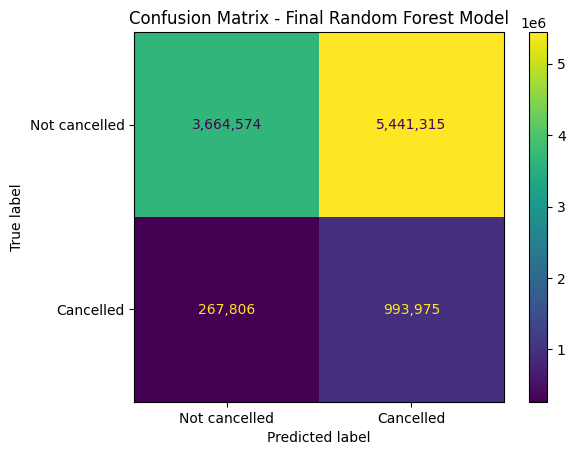

In [11]:
# Confusion matrix for test set
cm = confusion_matrix(
    test_pred_df["y_true"],
    test_pred_df["y_pred"]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not cancelled", "Cancelled"]
)

disp.plot(values_format=",d")
plt.title("Confusion Matrix - Final Random Forest Model")
plt.show()

In [12]:
# calculate error types:

test_pred_df["error_type"] = np.select(
    [
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 0) & (test_pred_df["y_pred"] == 1),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 0),
        (test_pred_df["y_true"] == 1) & (test_pred_df["y_pred"] == 1),
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive",
    ],
    default="Unknown"
)

print(test_pred_df["error_type"].value_counts())

error_type
False Positive    5441315
True Negative     3664574
True Positive      993975
False Negative     267806
Name: count, dtype: int64


# Subgroup bias analysis

In [13]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

# Subgroups are:
# StationCode_TE
# Service type
# Hour / RushHour
# IsWeekend
# StationTraffic

def subgroup_metrics(df, group_col):
    rows = []

    for group_value, group_df in df.groupby(group_col):
        if len(group_df) < 1000:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        rows.append({
            "group": group_value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

    return pd.DataFrame(rows).sort_values("f2", ascending=True)


print(subgroup_metrics(test_pred_df, "Service:Type_Intercity"))
print(subgroup_metrics(test_pred_df, "Service:Type_Sprinter"))
print(subgroup_metrics(test_pred_df, "IsWeekend"))
print(subgroup_metrics(test_pred_df, "RushHour"))

# For one-hot service type, create one readable service column first:
def get_service_type(row):
    if row["Service:Type_Intercity"] == 1:
        return "Intercity"
    elif row["Service:Type_Intercity direct"] == 1:
        return "Intercity direct"
    elif row["Service:Type_Sprinter"] == 1:
        return "Sprinter"
    else:
        return "Other"

test_pred_df["service_type"] = test_pred_df.apply(get_service_type, axis=1)

service_bias = subgroup_metrics(test_pred_df, "service_type")
print(service_bias)

   group        n  actual_cancel_rate  predicted_cancel_rate  \
0    0.0  7038088            0.094014               0.443818   
1    1.0  3329582            0.180233               0.994618   

   precision_cancelled  recall_cancelled        f2  
0             0.126632          0.597800  0.342746  
1             0.180702          0.997202  0.523823  
   group        n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  6846386            0.089536               0.429021   
0    0.0  3521284            0.184247               0.993401   

   precision_cancelled  recall_cancelled        f2  
1             0.118424          0.567441  0.322717  
0             0.184713          0.995917  0.530212  
   group        n  actual_cancel_rate  predicted_cancel_rate  \
1    1.0  2476407            0.088803               0.463377   
0    0.0  7891263            0.132028               0.670080   

   precision_cancelled  recall_cancelled        f2  
1             0.131913          0.688327  0.373359

# Rare Weather Conditions analysis

In [14]:
weather_flags = ["Fog", "Rainfall", "Snowfall", "Thunder", "Hail"]

weather_results = []

for weather_col in weather_flags:
    for value, group_df in test_pred_df.groupby(weather_col):
        if len(group_df) < 1000:
            continue

        y_true = group_df["y_true"]
        y_pred = group_df["y_pred"]

        weather_results.append({
            "weather_feature": weather_col,
            "condition_present": value,
            "n": len(group_df),
            "actual_cancel_rate": y_true.mean(),
            "predicted_cancel_rate": y_pred.mean(),
            "precision_cancelled": precision_score(y_true, y_pred, zero_division=0),
            "recall_cancelled": recall_score(y_true, y_pred, zero_division=0),
            "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
        })

weather_results_df = pd.DataFrame(weather_results).sort_values(
    ["weather_feature", "condition_present"]
)

print(weather_results_df)

  weather_feature  condition_present         n  actual_cancel_rate  \
0             Fog                0.0  10121445            0.122847   
1             Fog                1.0    246225            0.074680   
8            Hail                0.0  10352688            0.121804   
9            Hail                1.0     14982            0.052196   
2        Rainfall                0.0   8570441            0.120835   
3        Rainfall                1.0   1797229            0.125847   
4        Snowfall                0.0  10360674            0.121727   
5        Snowfall                1.0      6996            0.087193   
6         Thunder                0.0  10309093            0.121899   
7         Thunder                1.0     58577            0.087304   

   predicted_cancel_rate  precision_cancelled  recall_cancelled        f2  
0               0.624363             0.155194          0.788759  0.434223  
1               0.470456             0.114272          0.719872  0.349464  
8